# ATL012 bad Trial Gain fit

Exploration of `ATL012.2023-02-14.703`, focusing on environment ID 1 (the mouse's first-experienced environment, array slot 0).

Questions:

- Is the stored per-trial gain regression itself sensible?
- Are a few trials or neurons dominating the failure?
- Does the temporal structured-gain model validate at a rank that fails on test?
- Are trial count and rank saturation associated with poor fits across the cohort?

This is intentionally a scratch notebook: simple plots, direct inspection, and no figure-polishing.


In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import spearmanr

from dimilibi import measure_r2, mse
from vrAnalysis.database import get_database

from dimensionality_manuscript import (
    GainRegressionConfig,
    ResultsAggregator,
    ResultsStore,
    TrialPlacecellRegressionConfig,
)
from dimensionality_manuscript.env_order import load_env_order
from dimensionality_manuscript.registry import PopulationRegistry, get_model
from dimensionality_manuscript.regression_models.hyperparameters import PlaceFieldStructuredGainHyperparameters
from dimensionality_manuscript.trial_registry import EnvironmentTrialRegistry, TrialRegistryParameters

BAD_SESSION_UID = "ATL012.2023-02-14.703"
BAD_ENVIRONMENT = 1
BAD_SLOT = 0
TRIAL_GAIN_MODEL = "internal_placefield_1d_structured_gain"

sessiondb = get_database("vrSessions")
sessions = sessiondb.iter_sessions(
    imaging=True,
    experimentType="Blender VR",
    session_params={"spks_type": "sigrebase"},
)
session = next(s for s in sessions if s.session_uid == BAD_SESSION_UID)

store = ResultsStore()
gain_config = GainRegressionConfig()
trial_config = TrialPlacecellRegressionConfig()
results_gain = ResultsAggregator(gain_config, store, sessions)
results_trial = ResultsAggregator(trial_config, store, sessions)

bad_row = results_trial.session_ids.index(BAD_SESSION_UID)
env_order = load_env_order()[session.mouse_name]

print("session:", session.session_uid)
print("environment order:", env_order)
print("bad array slot:", BAD_SLOT, "actual environment:", env_order[BAD_SLOT])
print("results row:", bad_row)


session: ATL012.2023-02-14.703
environment order: [1, 3, 4]
bad array slot: 0 actual environment: 1
results row: 13


## 1. Stored temporal-model performance for this session

This reproduces the six-by-three array, labels the environment slots explicitly, and plots each environment separately.


,slot 0: env 1,slot 1: env 3,slot 2: env 4
external_placefield_1d,0.044309,0.082362,NaN
external_placefield_1d_gain,0.078742,0.094095,NaN
internal_placefield_1d,0.054152,0.087539,NaN
internal_placefield_1d_gain,0.078985,0.090986,NaN
internal_placefield_1d_structured_gain,-9.678718,0.113085,NaN
rrr,NaN,NaN,NaN


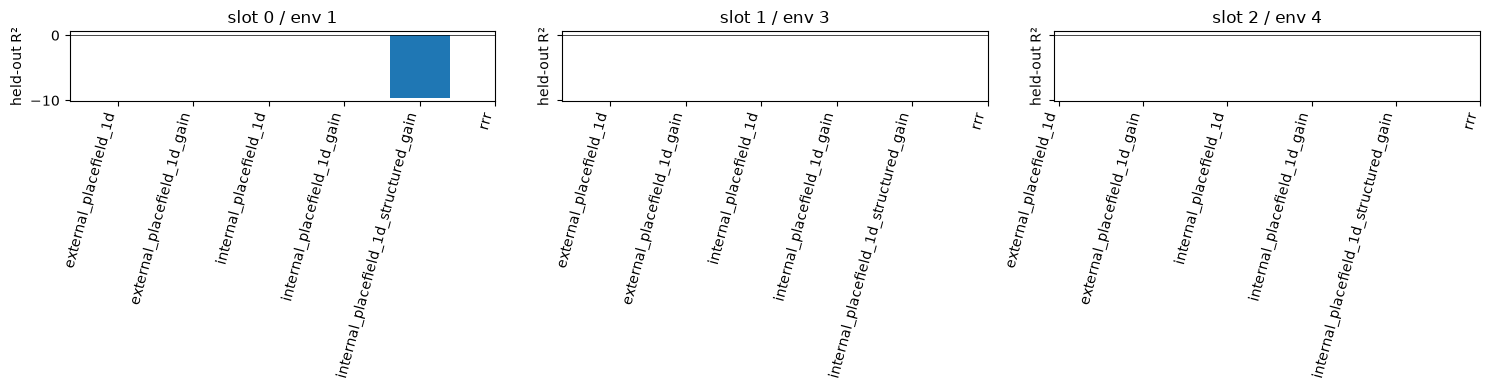

In [2]:
trial_keys = [
    "env_slot_ids",
    "r2",
    "mse",
    "n_trials_train",
    "n_trials_validation",
    "n_trials_test",
    "n_source_rois",
    "n_target_rois",
    "structured_gain_requested_rank",
    "structured_gain_effective_rank",
    "structured_gain_max_trial_rank",
]
trial_out = results_trial.sel(keys=trial_keys, squeeze_ones=False)
model_names = list(results_trial.param_axes["model_name"])
env_ids = np.asarray(trial_out["env_slot_ids"][bad_row, 0], dtype=float)

r2_session = np.asarray(trial_out["r2"][bad_row], dtype=float)
display(pd.DataFrame(r2_session, index=model_names, columns=[f"slot {i}: env {v:g}" for i, v in enumerate(env_ids)]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for slot, ax in enumerate(axes):
    ax.bar(np.arange(len(model_names)), r2_session[:, slot])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"slot {slot} / env {env_ids[slot]:g}")
    ax.set_xticks(np.arange(len(model_names)), model_names, rotation=75, ha="right")
    ax.set_ylabel("held-out R²")
plt.tight_layout()


## 2. Stored GainRegression performance for the same session

Each row is one combination of:

- place-field template from train trials or all trials;
- Gaussian or least-squares gain estimator;
- raw gain or square-root-transformed gain.

The red marks are trial-permuted null scores. This is a separate analysis from the temporal Trial Gain model, but the `train / least_squares / raw` row is the closest match to its gain definition.


,pf_split,estimator,transform,slot,environment,r2_val,r2_test,r2_test_null,rank,max_rank,n_trials,n_train,n_val,n_test,n_source,n_target
12,all,gaussian,raw,0,1,-0.001306,-0.007491,-0.071810,10.0,20.0,30.0,20.0,4.0,6.0,232.0,232.0
15,all,gaussian,sqrt,0,1,0.098241,0.166060,0.005360,8.0,20.0,30.0,20.0,4.0,6.0,232.0,232.0
18,all,least_squares,raw,0,1,0.032996,-0.014019,-0.068540,10.0,20.0,30.0,20.0,4.0,6.0,232.0,232.0
21,all,least_squares,sqrt,0,1,0.120607,0.151005,0.004166,8.0,20.0,30.0,20.0,4.0,6.0,232.0,232.0
0,train,gaussian,raw,0,1,0.124096,0.062236,-0.062409,8.0,20.0,30.0,20.0,4.0,6.0,232.0,233.0
3,train,gaussian,sqrt,0,1,0.290255,0.253186,0.030968,8.0,20.0,30.0,20.0,4.0,6.0,232.0,233.0
6,train,least_squares,raw,0,1,0.143104,0.068998,-0.052776,11.0,20.0,30.0,20.0,4.0,6.0,232.0,233.0
9,train,least_squares,sqrt,0,1,0.305786,0.240704,0.029350,9.0,20.0,30.0,20.0,4.0,6.0,232.0,233.0


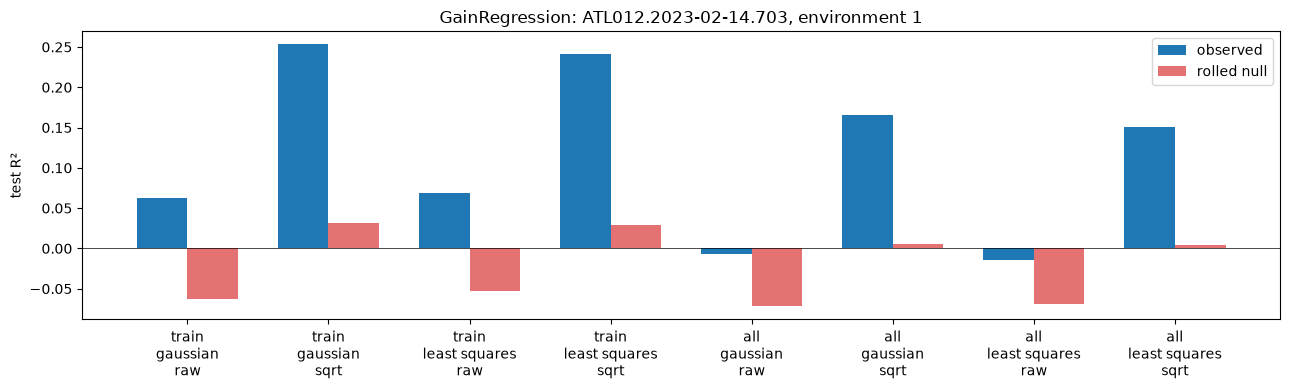

In [3]:
gain_rows = []
for pf_split in ("train", "all"):
    for estimator in ("gaussian", "least_squares"):
        for transform in ("raw", "sqrt"):
            selected = results_gain.sel(
                keys=[
                    "env_slot_ids", "r2_val", "r2_test", "r2_test_null",
                    "rrr_rank", "max_rank", "n_trials_env",
                    "n_trials_train", "n_trials_val", "n_trials_test",
                    "n_neurons_source", "n_neurons_target",
                ],
                squeeze_ones=False,
                placefield_split=pf_split,
                gain_estimator=estimator,
                gain_transform=transform,
            )
            for slot, env_id in enumerate(np.asarray(selected["env_slot_ids"][bad_row], dtype=float)):
                if not np.isfinite(env_id):
                    continue
                gain_rows.append({
                    "pf_split": pf_split,
                    "estimator": estimator,
                    "transform": transform,
                    "slot": slot,
                    "environment": int(env_id),
                    "r2_val": selected["r2_val"][bad_row, slot],
                    "r2_test": selected["r2_test"][bad_row, slot],
                    "r2_test_null": selected["r2_test_null"][bad_row, slot],
                    "rank": selected["rrr_rank"][bad_row, slot],
                    "max_rank": selected["max_rank"][bad_row, slot],
                    "n_trials": selected["n_trials_env"][bad_row, slot],
                    "n_train": selected["n_trials_train"][bad_row, slot],
                    "n_val": selected["n_trials_val"][bad_row, slot],
                    "n_test": selected["n_trials_test"][bad_row, slot],
                    "n_source": selected["n_neurons_source"][bad_row, slot],
                    "n_target": selected["n_neurons_target"][bad_row, slot],
                })

gain_table = pd.DataFrame(gain_rows)
display(gain_table[gain_table.environment == BAD_ENVIRONMENT].sort_values(["pf_split", "estimator", "transform"]))

plot_table = gain_table[gain_table.environment == BAD_ENVIRONMENT].copy()
plot_table["label"] = (
    plot_table["pf_split"] + "\n" +
    plot_table["estimator"].str.replace("_", " ") + "\n" +
    plot_table["transform"]
)
x = np.arange(len(plot_table))
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - 0.18, plot_table.r2_test, width=0.36, label="observed")
ax.bar(x + 0.18, plot_table.r2_test_null, width=0.36, label="rolled null", color="tab:red", alpha=0.65)
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(x, plot_table.label)
ax.set_ylabel("test R²")
ax.set_title(f"GainRegression: {BAD_SESSION_UID}, environment {BAD_ENVIRONMENT}")
ax.legend()
plt.tight_layout()


### GainRegression rank curves

Validation chooses the rank; test shows whether that choice generalizes. Dashed lines are rolled-neuron null curves.


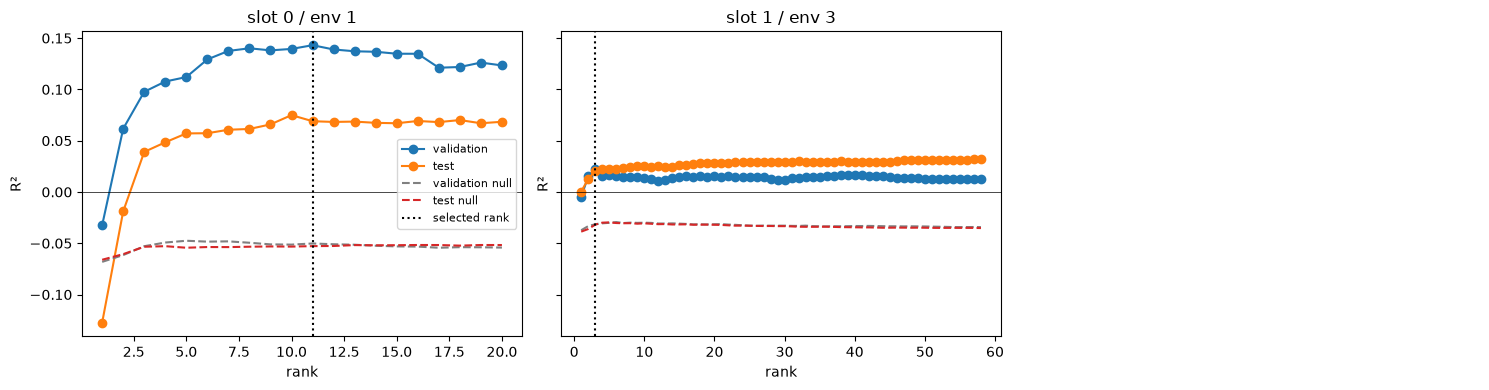

In [4]:
MATCHING_GAIN_SELECTION = dict(
    placefield_split="train",
    gain_estimator="least_squares",
    gain_transform="raw",
)
gain_curve_keys = [
    "env_slot_ids", "rank_values",
    "r2_val_curve", "r2_test_curve",
    "r2_val_curve_null", "r2_test_curve_null",
    "rrr_rank", "max_rank",
]
gain_curves = results_gain.sel(keys=gain_curve_keys, squeeze_ones=False, **MATCHING_GAIN_SELECTION)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for slot, ax in enumerate(axes):
    env_id = gain_curves["env_slot_ids"][bad_row, slot]
    ranks = np.asarray(gain_curves["rank_values"][bad_row, slot], dtype=float)
    valid = np.isfinite(ranks)
    ranks = ranks[valid]
    if not ranks.size:
        ax.set_axis_off()
        continue
    ax.plot(ranks, gain_curves["r2_val_curve"][bad_row, slot, valid], "o-", label="validation")
    ax.plot(ranks, gain_curves["r2_test_curve"][bad_row, slot, valid], "o-", label="test")
    ax.plot(ranks, gain_curves["r2_val_curve_null"][bad_row, slot, valid], "--", color="0.5", label="validation null")
    ax.plot(ranks, gain_curves["r2_test_curve_null"][bad_row, slot, valid], "--", color="tab:red", label="test null")
    ax.axvline(gain_curves["rrr_rank"][bad_row, slot], color="k", ls=":", label="selected rank")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"slot {slot} / env {env_id:g}")
    ax.set_xlabel("rank")
    ax.set_ylabel("R²")
axes[0].legend(fontsize=8)
plt.tight_layout()


## 3. Per-neuron × per-trial gain matrix

This uses the stored `train / least_squares / raw` GainRegression object data. Neurons are sorted by gain variability. The strip above the image shows train/validation/test membership of each trial column.


gain shape (neurons, trials): (465, 30)
source / target neurons: 232 233
trial split sizes: {'train': 20, 'val': 4, 'test': 6}


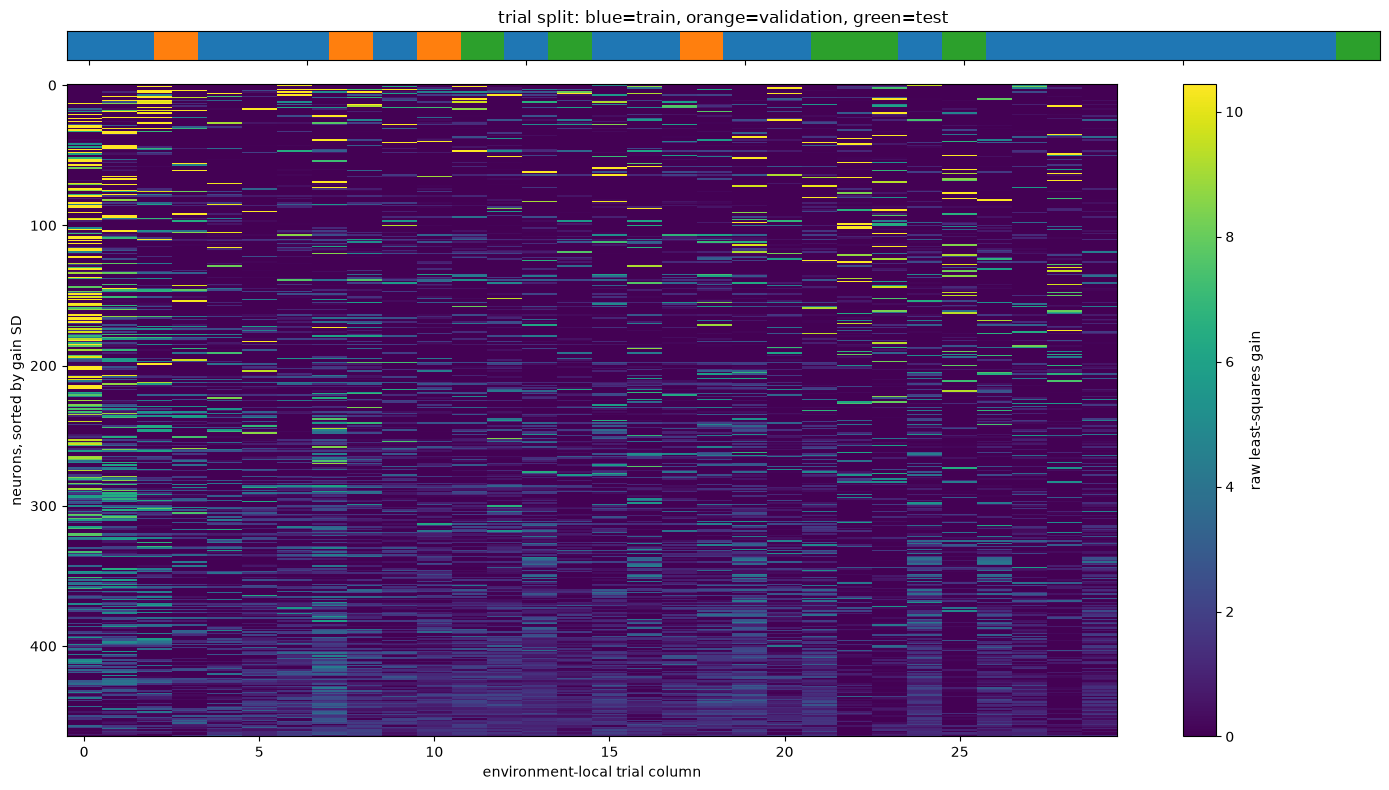

In [5]:
gain_objects = results_gain.sel_objects(
    keys=["gain_matrices", "gain_roi_indices", "source_rows", "target_rows", "trial_columns"],
    **MATCHING_GAIN_SELECTION,
)

gain = np.asarray(gain_objects["gain_matrices"][bad_row][BAD_SLOT], dtype=float)
gain_roi_ids = np.asarray(gain_objects["gain_roi_indices"][bad_row][BAD_SLOT], dtype=int)
source_rows = np.asarray(gain_objects["source_rows"][bad_row][BAD_SLOT], dtype=int)
target_rows = np.asarray(gain_objects["target_rows"][bad_row][BAD_SLOT], dtype=int)
trial_columns = gain_objects["trial_columns"][bad_row][BAD_SLOT]

split_code = np.full(gain.shape[1], -1, dtype=int)
for code_value, split_name in enumerate(("train", "val", "test")):
    split_code[np.asarray(trial_columns[split_name], dtype=int)] = code_value

neuron_order = np.argsort(np.nanstd(gain, axis=1))[::-1]
finite_gain = gain[np.isfinite(gain)]
vmax = np.nanpercentile(finite_gain, 99) if finite_gain.size else 1

fig, axes = plt.subplots(
    2, 1, figsize=(14, 8),
    gridspec_kw={"height_ratios": [0.35, 8]},
    sharex=True,
)
axes[0].imshow(split_code[None, :], aspect="auto", cmap=ListedColormap(["tab:blue", "tab:orange", "tab:green"]), vmin=0, vmax=2)
axes[0].set_yticks([])
axes[0].set_title("trial split: blue=train, orange=validation, green=test")
im = axes[1].imshow(gain[neuron_order], aspect="auto", interpolation="none", vmin=0, vmax=vmax, cmap="viridis")
axes[1].set_xlabel("environment-local trial column")
axes[1].set_ylabel("neurons, sorted by gain SD")
fig.colorbar(im, ax=axes[1], label="raw least-squares gain")
plt.tight_layout()

print("gain shape (neurons, trials):", gain.shape)
print("source / target neurons:", len(source_rows), len(target_rows))
print("trial split sizes:", {name: len(cols) for name, cols in trial_columns.items()})


### Which neurons have extreme or unstable gains?

The table keeps the original session ROI IDs. The source/target label refers to the cross-neuron gain regression split.


,gain_row,roi_id,group,mean_gain,sd_gain,max_gain,fraction_gain_gt_3
336,336,3505,source,3.120003,13.244123,73.552894,0.133333
380,380,3817,source,1.585722,5.097331,27.532008,0.133333
460,460,4754,target,2.207469,5.372319,24.164666,0.166667
410,410,4100,target,2.314569,4.928492,23.254626,0.233333
436,436,4403,target,1.407233,4.813681,22.216985,0.066667
345,345,3588,source,1.808063,4.025191,19.640237,0.133333
24,24,152,target,2.581075,4.578922,19.122416,0.266667
252,252,2785,target,1.271008,3.924130,18.130243,0.100000
237,237,2520,source,1.480467,3.588723,17.128790,0.133333
432,432,4355,source,0.685782,2.922200,16.310677,0.033333


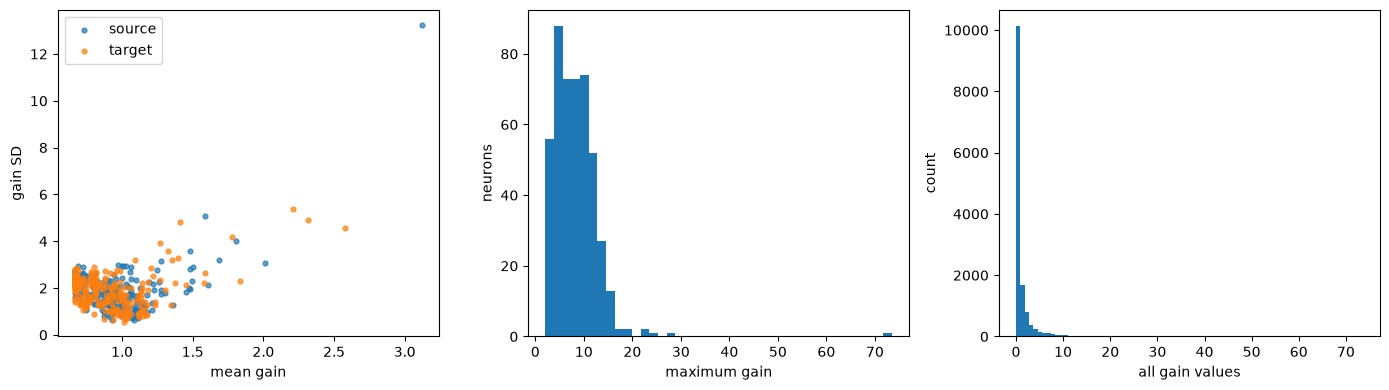

In [6]:
group = np.full(gain.shape[0], "other", dtype=object)
group[source_rows] = "source"
group[target_rows] = "target"

neuron_gain_stats = pd.DataFrame({
    "gain_row": np.arange(gain.shape[0]),
    "roi_id": gain_roi_ids,
    "group": group,
    "mean_gain": np.nanmean(gain, axis=1),
    "sd_gain": np.nanstd(gain, axis=1),
    "max_gain": np.nanmax(gain, axis=1),
    "fraction_gain_gt_3": np.nanmean(gain > 3, axis=1),
})
display(neuron_gain_stats.sort_values("max_gain", ascending=False).head(25))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name, color in (("source", "tab:blue"), ("target", "tab:orange")):
    use = neuron_gain_stats.group == name
    axes[0].scatter(neuron_gain_stats.loc[use, "mean_gain"], neuron_gain_stats.loc[use, "sd_gain"], s=12, alpha=0.7, label=name, color=color)
axes[0].set(xlabel="mean gain", ylabel="gain SD")
axes[0].legend()
axes[1].hist(neuron_gain_stats.max_gain, bins=40)
axes[1].set(xlabel="maximum gain", ylabel="neurons")
axes[2].hist(gain.ravel()[np.isfinite(gain.ravel())], bins=80)
axes[2].set(xlabel="all gain values", ylabel="count")
plt.tight_layout()


## 4. Rebuild the exact temporal Trial Gain fit

This cell reconstructs the environment-specific registry using the stored ROI selection and stored hyperparameters. It does not write a pipeline result. It may take a little while the first time because it loads the population and reruns the model.


In [7]:
trial_objects = results_trial.sel_objects(
    keys=[
        "selected_roi_indices",
        "source_roi_indices",
        "target_roi_indices",
        "selected_hyperparameters",
    ],
    model_name=TRIAL_GAIN_MODEL,
)

selected_rois = np.asarray(trial_objects["selected_roi_indices"][bad_row][BAD_SLOT], dtype=int)
stored_source_rois = np.asarray(trial_objects["source_roi_indices"][bad_row][BAD_SLOT], dtype=int)
stored_target_rois = np.asarray(trial_objects["target_roi_indices"][bad_row][BAD_SLOT], dtype=int)
stored_hp_dict = trial_objects["selected_hyperparameters"][bad_row][BAD_SLOT]
stored_hp = PlaceFieldStructuredGainHyperparameters(**stored_hp_dict)

trial_gain_config = TrialPlacecellRegressionConfig(model_name=TRIAL_GAIN_MODEL)
base_registry = PopulationRegistry(registry_params=trial_gain_config.data_config.to_registry_params())
env_registry = EnvironmentTrialRegistry(
    base_registry,
    BAD_ENVIRONMENT,
    selected_rois,
    TrialRegistryParameters(
        relative_size=(2, 1, 1),
        split_seed=trial_gain_config.trial_split_seed,
        speed_threshold=base_registry.registry_params.speed_threshold,
    ),
)
trial_gain_model = get_model(
    TRIAL_GAIN_MODEL,
    env_registry,
    activity_parameters=trial_gain_config.activity_parameters_name,
)

report = trial_gain_model.process(
    session,
    trial_gain_config.spks_type,
    train_split="train",
    test_split="test",
    hyperparameters=stored_hp,
)

prediction = np.asarray(report.predicted_data)
target = np.asarray(report.target_data)
print("stored hyperparameters:", stored_hp)
print("prediction / target shape:", prediction.shape, target.shape)
print("recomputed pooled R²:", float(measure_r2(prediction, target, reduce="mean", dim=None)))
print("recomputed MSE:", float(mse(prediction, target, reduce="mean", dim=None)))
print("gain model max rank:", report.trained_model[2].max_rank)


stored hyperparameters: PlaceFieldStructuredGainHyperparameters(num_bins=48, smooth_width=4.968138006093389, rank=16, alpha=879.5730415567407)
prediction / target shape: (226, 593) (226, 593)
recomputed pooled R²: -9.678718629395624
recomputed MSE: 61.76368767715472
gain model max rank: 16


## 5. Are a few target neurons or test trials causing the failure?

First inspect per-neuron and per-trial scores. Then remove the worst target neurons cumulatively and recompute pooled R². If a tiny number of neurons causes the collapse, the removal curve should recover quickly.


,target_row,roi_id,r2,mse,sse
112,112,2269,-79.657793,1290.869781,765485.780237
186,186,3757,-503.590072,1278.025665,757869.219050
176,176,3563,-124.960874,1187.002516,703892.492226
18,18,324,-124.005386,1134.279488,672627.736359
26,26,509,-73.773430,805.808776,477844.603936
30,30,533,-55.865157,636.939353,377705.036285
189,189,3808,-504.066970,612.953950,363481.692098
33,33,611,-50.678516,571.680736,339006.676691
129,129,2770,-79.307627,431.976390,256161.998974
89,89,1897,-22.349885,385.929953,228856.461940


,trial,n_frames,r2,mse
2,2,54,-47.359587,496.039248
1,1,54,-6.187338,92.714890
0,0,59,-2.356089,68.095513
7,92,105,-0.050161,1.649564
8,123,95,0.000591,1.271629
6,57,67,0.115417,1.400607
3,4,45,0.127640,3.571476
4,11,56,0.143810,2.685949
5,28,58,0.191038,2.009120


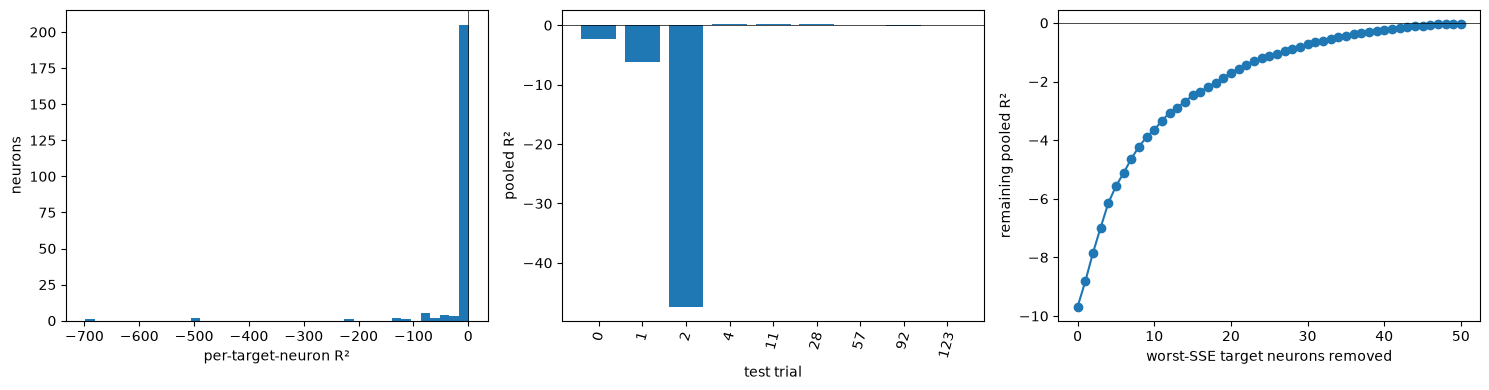

In [8]:
r2_roi = np.asarray(measure_r2(prediction, target, reduce="none", dim=1), dtype=float)
mse_roi = np.asarray(mse(prediction, target, reduce="none", dim=1), dtype=float)
sse_roi = np.sum((prediction - target) ** 2, axis=1)

population, _ = env_registry.get_population(session, trial_gain_config.spks_type)
population_rois = np.asarray(population.idx_neurons.detach().cpu(), dtype=int)
target_local = np.asarray(population.cell_split_indices[1].detach().cpu(), dtype=int)
target_roi_ids = population_rois[target_local]

neuron_fit = pd.DataFrame({
    "target_row": np.arange(target.shape[0]),
    "roi_id": target_roi_ids,
    "r2": r2_roi,
    "mse": mse_roi,
    "sse": sse_roi,
})
display(neuron_fit.sort_values("sse", ascending=False).head(25))

frame_trials = np.asarray(report.extras["frame_behavior"].trial, dtype=int)
trial_fit_rows = []
for trial in np.unique(frame_trials):
    use = frame_trials == trial
    trial_fit_rows.append({
        "trial": int(trial),
        "n_frames": int(use.sum()),
        "r2": float(measure_r2(prediction[:, use], target[:, use], reduce="mean", dim=None)),
        "mse": float(mse(prediction[:, use], target[:, use], reduce="mean", dim=None)),
    })
trial_fit = pd.DataFrame(trial_fit_rows)
display(trial_fit.sort_values("r2"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(r2_roi[np.isfinite(r2_roi)], bins=40)
axes[0].axvline(0, color="k", lw=0.5)
axes[0].set(xlabel="per-target-neuron R²", ylabel="neurons")
axes[1].bar(trial_fit.trial.astype(str), trial_fit.r2)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].tick_params(axis="x", rotation=75)
axes[1].set(xlabel="test trial", ylabel="pooled R²")

worst_first = np.argsort(sse_roi)[::-1]
remove_counts = np.arange(0, min(50, target.shape[0] - 2) + 1)
r2_after_removal = []
for n_remove in remove_counts:
    keep = np.ones(target.shape[0], dtype=bool)
    keep[worst_first[:n_remove]] = False
    r2_after_removal.append(float(measure_r2(prediction[keep], target[keep], reduce="mean", dim=None)))
axes[2].plot(remove_counts, r2_after_removal, "o-")
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set(xlabel="worst-SSE target neurons removed", ylabel="remaining pooled R²")
plt.tight_layout()


## 6. Does the validation-selected temporal rank generalize?

The model was stored at rank 16, exactly the available maximum. This cell reuses the same trained place fields and gain regression, changing only the prediction-time rank. Validation and test therefore remain directly comparable.


,rank,validation_r2,test_r2,validation_mse,test_mse
0,1,0.065682,-15.839805,2.151716,97.398251
1,2,0.184545,-9.559669,1.877976,61.075132
2,3,0.206447,-9.558941,1.827537,61.070921
3,4,0.215561,-9.584263,1.806546,61.217378
4,5,0.215447,-9.627475,1.806809,61.467311
5,6,0.214741,-9.652516,1.808435,61.612140
6,7,0.214808,-9.643405,1.808282,61.559444
7,8,0.217467,-9.544360,1.802157,60.986589
8,9,0.218586,-9.545697,1.799581,60.994322
9,10,0.219018,-9.687458,1.798587,61.814237


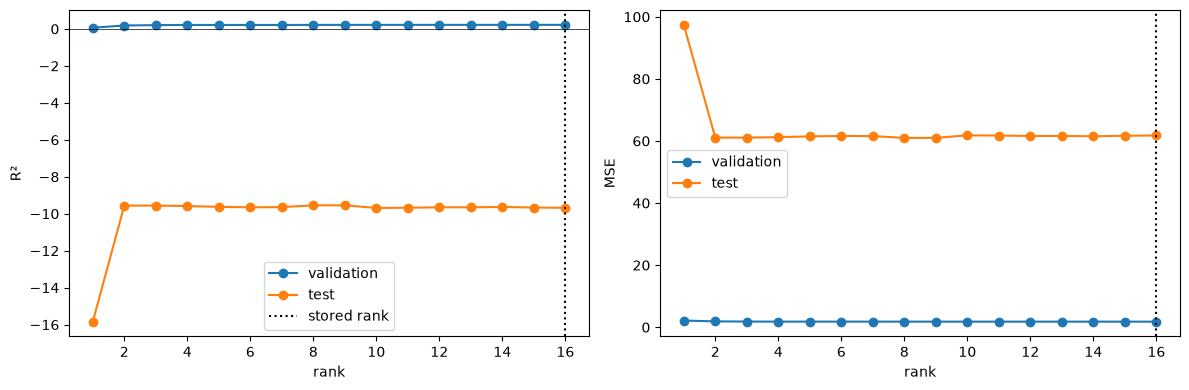

In [14]:
def score_temporal_split(coefficients, split, rank):
    hp = replace(stored_hp, rank=int(rank))
    pred, extras = trial_gain_model.predict(
        session,
        coefficients,
        spks_type=trial_gain_config.spks_type,
        split=split,
        hyperparameters=hp,
    )
    truth = np.asarray(
        trial_gain_model.get_session_data(session, trial_gain_config.spks_type, split)[1],
        dtype=float,
    )
    if extras.get("predictions_were_filtered", False):
        truth = truth[:, extras["idx_valid_predictions"]]
    return (
        float(measure_r2(np.asarray(pred), truth, reduce="mean", dim=None)),
        float(mse(np.asarray(pred), truth, reduce="mean", dim=None)),
    )

coefficients = report.trained_model
max_rank = int(coefficients[2].max_rank)
ranks = np.arange(1, max_rank + 1)
validation_scores = np.array([score_temporal_split(coefficients, "validation", rank) for rank in ranks])
test_scores = np.array([score_temporal_split(coefficients, "test", rank) for rank in ranks])

rank_table = pd.DataFrame({
    "rank": ranks,
    "validation_r2": validation_scores[:, 0],
    "test_r2": test_scores[:, 0],
    "validation_mse": validation_scores[:, 1],
    "test_mse": test_scores[:, 1],
})
display(rank_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ranks, validation_scores[:, 0], "o-", label="validation")
axes[0].plot(ranks, test_scores[:, 0], "o-", label="test")
axes[0].axvline(stored_hp.rank, color="k", ls=":", label="stored rank")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set(xlabel="rank", ylabel="R²")
axes[0].legend()
axes[1].plot(ranks, validation_scores[:, 1], "o-", label="validation")
axes[1].plot(ranks, test_scores[:, 1], "o-", label="test")
axes[1].axvline(stored_hp.rank, color="k", ls=":")
axes[1].set(xlabel="rank", ylabel="MSE")
axes[1].legend()
plt.tight_layout()


### Optional: alpha × rank surface

This is more expensive, but it directly tests whether the stored alpha/rank pair sits on a narrow validation optimum that explodes on test. Place fields are held fixed; only the source-to-target gain regression is refit.


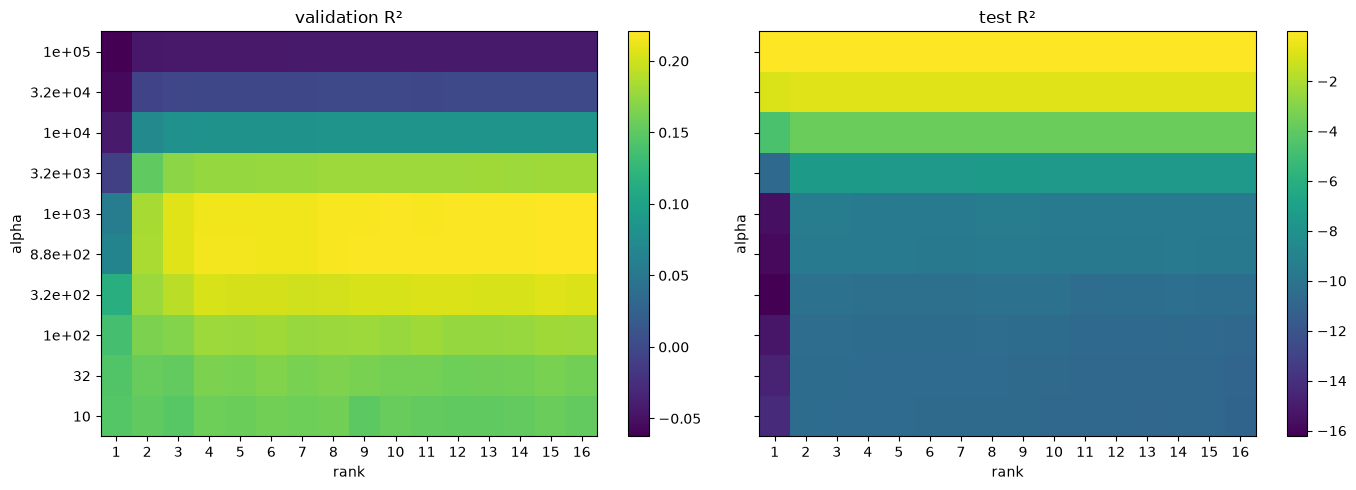

In [15]:
# Run this cell if the rank-only curve suggests instability.
target_placefield, source_placefield, _ = report.trained_model
alphas = np.unique(np.r_[np.logspace(1, 5, 9), stored_hp.alpha])
ranks = np.arange(1, max_rank + 1)

surface_val = np.full((len(alphas), len(ranks)), np.nan)
surface_test = np.full_like(surface_val, np.nan)

for ia, alpha in enumerate(alphas):
    gain_model = trial_gain_model.fit_gain_model(
        session,
        target_placefield,
        source_placefield,
        spks_type=trial_gain_config.spks_type,
        split="train",
        alpha=float(alpha),
    )
    coeff = (target_placefield, source_placefield, gain_model)
    for ir, rank in enumerate(ranks):
        surface_val[ia, ir] = score_temporal_split(coeff, "validation", rank)[0]
        surface_test[ia, ir] = score_temporal_split(coeff, "test", rank)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, values, title in zip(axes, (surface_val, surface_test), ("validation R²", "test R²")):
    im = ax.imshow(values, aspect="auto", origin="lower", interpolation="none")
    ax.set_xticks(np.arange(len(ranks)), ranks)
    ax.set_yticks(np.arange(len(alphas)), [f"{a:.2g}" for a in alphas])
    ax.set(xlabel="rank", ylabel="alpha", title=title)
    fig.colorbar(im, ax=ax)
plt.tight_layout()


## 7. Are trial count or rank saturation associated with bad fits across sessions?

Each point is a session/environment. The left panel uses the absolute Trial Gain score; the middle uses improvement over Internal PF; the right compares the fraction of available rank selected. The bad cell is highlighted in red.


Spearman(training trials, Trial Gain R²): SignificanceResult(statistic=-0.25168346579171674, pvalue=3.176726560666201e-05)
Spearman(training trials, gain improvement): SignificanceResult(statistic=0.2585393913630262, pvalue=1.8883456641384687e-05)
Spearman(rank fraction, gain improvement): SignificanceResult(statistic=0.3943296932734889, pvalue=2.2927335318502513e-11)


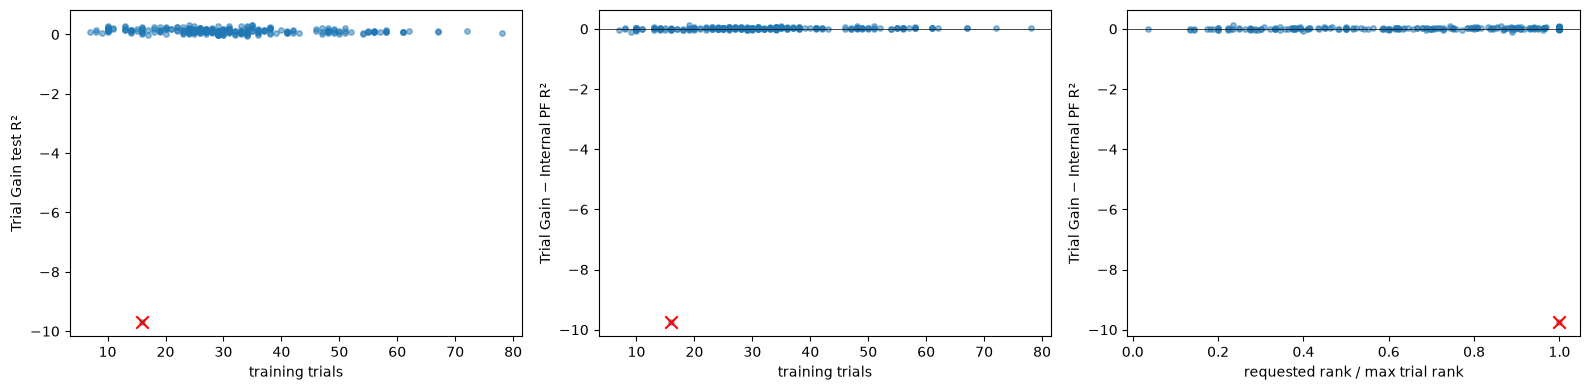

In [16]:
cohort = results_trial.sel(
    keys=[
        "r2", "n_trials_train", "n_trials_validation", "n_trials_test",
        "structured_gain_requested_rank", "structured_gain_max_trial_rank", "env_slot_ids",
    ],
    squeeze_ones=False,
)
model_index = {name: i for i, name in enumerate(model_names)}
gain_idx = model_index[TRIAL_GAIN_MODEL]
pf_idx = model_index["internal_placefield_1d"]

gain_r2 = np.asarray(cohort["r2"][:, gain_idx], dtype=float)
pf_r2 = np.asarray(cohort["r2"][:, pf_idx], dtype=float)
delta_r2 = gain_r2 - pf_r2
n_train = np.asarray(cohort["n_trials_train"][:, gain_idx], dtype=float)
n_val = np.asarray(cohort["n_trials_validation"][:, gain_idx], dtype=float)
n_test = np.asarray(cohort["n_trials_test"][:, gain_idx], dtype=float)
requested_rank = np.asarray(cohort["structured_gain_requested_rank"][:, gain_idx], dtype=float)
max_trial_rank = np.asarray(cohort["structured_gain_max_trial_rank"][:, gain_idx], dtype=float)
rank_fraction = requested_rank / max_trial_rank

bad_point = np.zeros(gain_r2.shape, dtype=bool)
bad_point[bad_row, BAD_SLOT] = True
finite = np.isfinite(gain_r2) & np.isfinite(n_train)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(n_train[finite], gain_r2[finite], s=15, alpha=0.5)
axes[0].scatter(n_train[bad_point], gain_r2[bad_point], s=80, color="red", marker="x")
axes[0].set(xlabel="training trials", ylabel="Trial Gain test R²")
axes[1].scatter(n_train[finite], delta_r2[finite], s=15, alpha=0.5)
axes[1].scatter(n_train[bad_point], delta_r2[bad_point], s=80, color="red", marker="x")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set(xlabel="training trials", ylabel="Trial Gain − Internal PF R²")
rank_ok = finite & np.isfinite(rank_fraction)
axes[2].scatter(rank_fraction[rank_ok], delta_r2[rank_ok], s=15, alpha=0.5)
axes[2].scatter(rank_fraction[bad_point], delta_r2[bad_point], s=80, color="red", marker="x")
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set(xlabel="requested rank / max trial rank", ylabel="Trial Gain − Internal PF R²")
plt.tight_layout()

print("Spearman(training trials, Trial Gain R²):", spearmanr(n_train[finite], gain_r2[finite]))
print("Spearman(training trials, gain improvement):", spearmanr(n_train[finite], delta_r2[finite]))
print("Spearman(rank fraction, gain improvement):", spearmanr(rank_fraction[rank_ok], delta_r2[rank_ok]))


In [17]:
# Closest cohort matches by training-trial count, for an eyeball comparison.
flat_rows = []
for row, session_uid in enumerate(results_trial.session_ids):
    for slot in range(gain_r2.shape[1]):
        if not np.isfinite(gain_r2[row, slot]):
            continue
        flat_rows.append({
            "session": session_uid,
            "slot": slot,
            "environment": cohort["env_slot_ids"][row, gain_idx, slot],
            "n_train": n_train[row, slot],
            "n_val": n_val[row, slot],
            "n_test": n_test[row, slot],
            "rank": requested_rank[row, slot],
            "max_rank": max_trial_rank[row, slot],
            "trial_gain_r2": gain_r2[row, slot],
            "internal_pf_r2": pf_r2[row, slot],
            "delta_r2": delta_r2[row, slot],
        })
cohort_table = pd.DataFrame(flat_rows)
display(
    cohort_table.assign(distance=(cohort_table.n_train - n_train[bad_row, BAD_SLOT]).abs())
    .sort_values(["distance", "trial_gain_r2"])
    .head(30)
)


,session,slot,environment,n_train,n_val,n_test,rank,max_rank,trial_gain_r2,internal_pf_r2,delta_r2,distance
20,ATL012.2023-02-14.703,0,1.0,16.0,8.0,9.0,16.0,16.0,-9.678718,0.054152,-9.732870,0.0
138,CR_Hippocannula7.2022-08-30.701,1,2.0,16.0,8.0,8.0,11.0,16.0,0.018420,0.047651,-0.029230,0.0
75,ATL022.2023-04-24.701,2,4.0,16.0,8.0,9.0,8.0,16.0,0.057529,0.045415,0.012115,0.0
81,ATL022.2023-04-26.701,2,4.0,16.0,8.0,9.0,13.0,13.0,0.088650,0.086030,0.002620,0.0
10,ATL012.2023-02-02.701,0,1.0,16.0,8.0,8.0,9.0,15.0,0.116485,0.140562,-0.024076,0.0
14,ATL012.2023-02-07.701,0,1.0,16.0,8.0,9.0,10.0,16.0,0.174246,0.172630,0.001616,0.0
82,ATL022.2023-04-27.702,0,3.0,16.0,8.0,8.0,11.0,16.0,0.207427,0.182935,0.024492,0.0
30,ATL012.2023-02-21.702,0,1.0,16.0,8.0,8.0,3.0,16.0,0.262280,0.261795,0.000484,0.0
7,ATL012.2023-01-30.702,1,3.0,17.0,8.0,9.0,4.0,17.0,-0.021163,-0.013973,-0.007190,1.0
37,ATL012.2023-02-27.701,1,3.0,15.0,8.0,8.0,2.0,15.0,0.129942,0.167543,-0.037601,1.0


## What I would check next

After running the cells above:

1. **Rank-only curve:** if low ranks are sane and rank 16 alone collapses, this is a validation-selection/overfitting outlier.
2. **Alpha × rank surface:** if the test collapse occupies a narrow high-rank/low-regularization corner, the fit is technically unstable rather than biologically exceptional.
3. **Per-trial scores:** one disastrous test trial suggests split sensitivity; broadly bad test trials suggest session-level mismatch.
4. **Neuron removal curve:** rapid recovery after removing a few neurons implicates heavy-tailed cell gains or poorly estimated target place fields.
5. **GainRegression raw vs sqrt:** improvement under sqrt implicates the heavy gain tail.
6. **Cohort trial-count plot:** if similarly trial-limited fits are usually fine, trial count alone cannot explain this cell.

A useful follow-up, if needed, is seed sensitivity: rerun only this session/environment across several `trial_split_seed` values and plot the selected rank and test R². That is intentionally not automated here because each seed performs a fresh hyperparameter optimization.
